In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit

In [2]:
def modelo_lineal(theta_0, theta_1, x):
  return theta_0 + theta_1 * x

def funcion_coste_cuadratico(X, Y, modelo, theta_0, theta_1):
    
  Y_modelo = modelo(theta_0, theta_1, X)
  return np.sum((Y_modelo - Y)**2, axis=-1) / 2



In [3]:
X = np.linspace(3.5267, 5.9876, 100)
Y = 3.4355 + X * (-1.8746)
XY = {"X": X, "Y":Y}
df = pd.DataFrame(XY)

In [4]:
X_grid = X[:,None]
Y_grid = Y[:,None]
np.sum(X_grid-Y_grid)

np.float64(1023.940339)

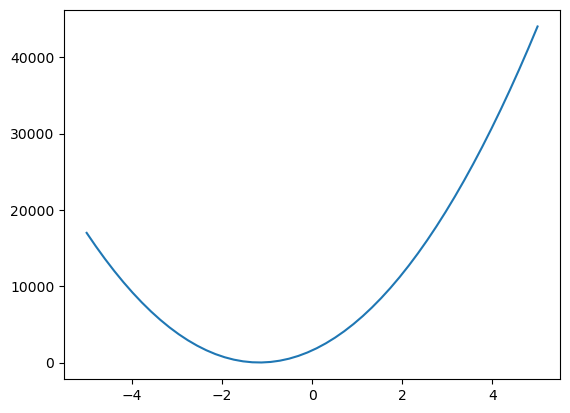

In [5]:
### theta_0 = 0
null_theta_0 = 0

thetas_1 = np.linspace(-5,5,50)
costes = np.array([funcion_coste_cuadratico(X,Y,modelo_lineal,null_theta_0,pendiente) for pendiente in thetas_1])

plt.plot(thetas_1, costes)
plt.show()

In [7]:
# dos dé
N = 101
THETA_1 = np.linspace(-5, 5, N)
THETA_0 = np.linspace(-5, 5, N)
coste = []
xs, ys = np.meshgrid(ths_0, ths_1)
@njit
for b in THETA_0:
    for m in THETA_1:
        costes.append(funcion_coste_cuadratico(X, Y, modelo, b, m))





fig = plt.contour(ths_0, ths_1, costes_2d)
#plt.axis('scaled')
#plt.colorbar()
#plt.show()

SyntaxError: invalid syntax (1553375972.py, line 8)

In [14]:
N = 101
THETA_1 = np.linspace(-5, 5, N)
THETA_0 = np.linspace(-5, 5, N)

# 1. Encapsulamos la lógica dentro de una función decorada
@njit
def calcular_malla_costes(THETA_0, THETA_1, X, Y):
    n0 = len(THETA_0)
    n1 = len(THETA_1)
    costes_2d = np.zeros((n0, n1))  # Matriz preasignada para Numba
    
    for i in range(n0):
        for j in range(n1):
            b = THETA_0[i]
            m = THETA_1[j]
            # Asegurate de que funcion_coste_cuadratico también sea compatible con Numba
            costes_2d[i, j] = funcion_coste_cuadratico(X, Y, modelo, b, m)
            
    return costes_2d

# 2. Ejecutamos la función
costes_2d = calcular_malla_costes(THETA_0, THETA_1, X, Y)

# 3. Graficamos directamente
fig = plt.contour(THETA_0, THETA_1, costes_2d)
plt.colorbar(fig)
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mUntyped global name 'funcion_coste_cuadratico':[0m [1m[1mCannot determine Numba type of <class 'function'>[0m
[1m
File "..\..\..\..\..\..\AppData\Local\Temp\ipykernel_9424\4243638592.py", line 17:[0m
[1m<source missing, REPL/exec in use?>[0m
[0m
[0m[1mDuring: Pass nopython_type_inference[0m

In [39]:
N = 400
a = -40
b = 40
N = 200
THETA_1 = np.linspace(a, b, N)
THETA_0 = np.linspace(a, b, N)
# 1. Tanto la función de coste como la de la malla DEBEN tener @njit
@njit
def funcion_coste_cuadratico(X, Y, b, m):
    # Operación vectorial pura de NumPy sobre arrays de C
    y_pred = m * X + b
    return np.mean((Y - y_pred) ** 2)

@njit
def calcular_malla_costes(THETA_0, THETA_1, X, Y):
    n0 = len(THETA_0)
    n1 = len(THETA_1)
    costes_2d = np.zeros((n0, n1))
    
    for i in range(n0):
        for j in range(n1):
            costes_2d[i, j] = funcion_coste_cuadratico(X, Y, THETA_0[i], THETA_1[j])
            
    return costes_2d

# Ejecución
costes_2d = calcular_malla_costes(THETA_0, THETA_1, X, Y)

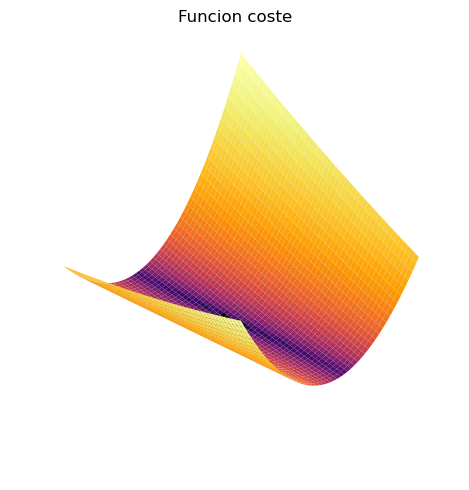

In [43]:
plot_surface(costes_2d, 'Funcion coste', N,a,b)

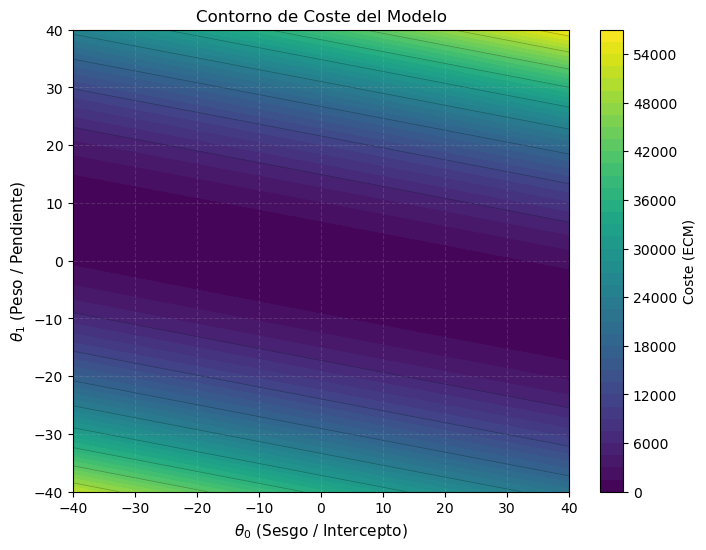

In [44]:
def graficar_superficie_coste(ths_0, ths_1, costes_2d, label_x="Eje X", label_y="Eje Y", titulo="Superficie de Coste"):
    plt.figure(figsize=(8, 6))

    # Mapa de calor relleno
    mapa = plt.contourf(ths_0, ths_1, costes_2d.T, levels=50, cmap='viridis')

    # Líneas topográficas de nivel
    plt.contour(ths_0, ths_1, costes_2d.T, levels=10, colors='black', alpha=0.3, linewidths=0.5)

    # Configuración de ejes e información visual
    plt.xlabel(label_x, fontsize=11)
    plt.ylabel(label_y, fontsize=11)
    plt.title(titulo, fontsize=12)
    plt.colorbar(mapa, label='Coste (ECM)')
    plt.grid(True, linestyle='--', alpha=0.2)
    
    plt.show()

# Ejemplo de llamada:
graficar_superficie_coste(
    THETA_0, 
    THETA_1, 
    costes_2d, 
    label_x=r"$\theta_0$ (Sesgo / Intercepto)", 
    label_y=r"$\theta_1$ (Peso / Pendiente)",
    titulo="Contorno de Coste del Modelo"
)

In [45]:
np.argmin(costes_2d)

np.int64(21495)

In [42]:
from matplotlib.colors import PowerNorm, LogNorm
def plot_surface(Z, title, N, a, b):
    x = np.linspace(a,b,N)
    X1, X2 = np.meshgrid(x, x)

    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X1, X2, Z,
        cmap='inferno',
        shade=False,
        edgecolor='none',
        norm=PowerNorm(gamma=0.2),
        linewidth=1,
        antialiased=True
    )

    ax.view_init(elev=45, azim=225)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

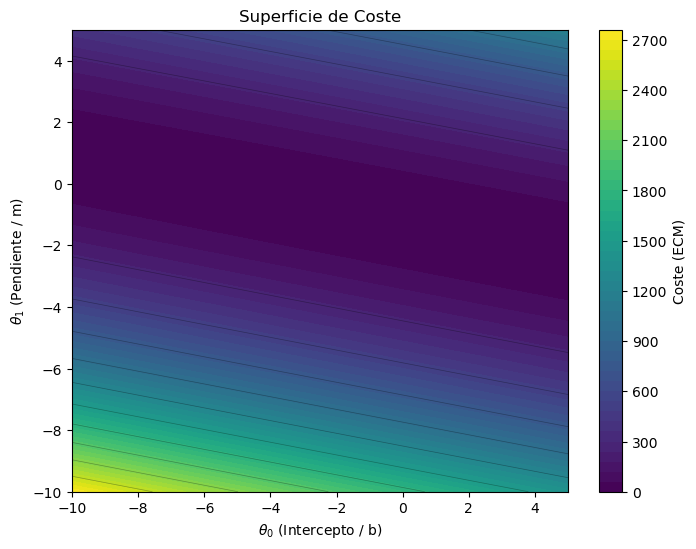

In [21]:
plt.figure(figsize=(8, 6))

# 1. Usar contourf (Relleno) con mas niveles (levels=50) y paleta continua
# Nota: Si b estaba en filas y m en columnas, poné costes_2d.T para alinear los ejes
mapa = plt.contourf(THETA_0, THETA_1, costes_2d.T, levels=50, cmap='viridis')

# 2. (Opcional) Tirar lineas negras finas encima para dar efecto topografico
plt.contour(THETA_0, THETA_1, costes_2d.T, levels=10, colors='black', alpha=0.3, linewidths=0.5)

plt.colorbar(mapa, label='Coste (ECM)')
plt.xlabel(r'$\theta_0$ (Intercepto / b)')
plt.ylabel(r'$\theta_1$ (Pendiente / m)')
plt.title('Superficie de Coste')
plt.show()